In [ ]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
from google.colab import files

# This will prompt you to select the file from your local folder
uploaded = files.upload()

Saving 3_spotify_5000_songs.csv to 3_spotify_5000_songs (1).csv


In [ ]:
spotify_df = pd.read_csv('3_spotify_5000_songs.csv')

In [ ]:
spotify_df.head()

,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


In [ ]:
spotify_df.describe()

,Unnamed: 0,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
count,5235.00000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5.235000e+03,5235.000000
mean,2617.00000,0.509503,0.653565,5.254441,-9.338098,0.646227,0.083178,0.290043,0.257337,0.185354,0.443596,118.721407,2.479112e+05,3.902961
std,1511.35866,0.218041,0.288335,3.571559,6.294850,0.478185,0.071193,0.355985,0.370686,0.149410,0.277725,28.568463,1.356330e+05,0.420324
min,0.00000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.276000e+04,0.000000
25%,1308.50000,0.309000,0.479000,2.000000,-11.337000,0.000000,0.039000,0.002450,0.000001,0.092500,0.196000,96.174000,1.899910e+05,4.000000
50%,2617.00000,0.539000,0.738000,5.000000,-7.338000,1.000000,0.055800,0.095400,0.001880,0.125000,0.417000,119.180000,2.246670e+05,4.000000
75%,3925.50000,0.688000,0.893000,8.000000,-5.264000,1.000000,0.098650,0.565500,0.643000,0.237000,0.677000,134.019000,2.717200e+05,4.000000
max,5234.00000,0.967000,1.000000,11.000000,1.342000,1.000000,0.918000,0.996000,0.985000,0.987000,0.985000,213.990000,3.815787e+06,5.000000


Drop the "Noise" column

In [ ]:
# Drop the index column and any other non-audio features
# We keep only the numeric audio features for the model
spotify_features = spotify_df.drop(columns=['Unnamed: 0'], errors='ignore')
spotify_features.head()

,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html
0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.2590,11,-13.141,0,0.0705,0.694,0.000059,0.975,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...
1,Saudade De Bahia ...,Antônio Carlos Jobim,0.742,0.3990,2,-12.646,1,0.0346,0.217,0.000002,0.107,0.693,125.039,,191867,4,5QGM1U0eCYrQuwSJwTm5Zq,https://open.spotify.com/track/5QGM1U0eCYrQuwS...
2,"Canta Canta, Minha Gente ...",Martinho Da Vila,0.851,0.7300,2,-11.048,1,0.3470,0.453,0.000063,0.124,0.905,93.698,,152267,4,0NLIFSZxPzQhCwnkn5PJYs,https://open.spotify.com/track/0NLIFSZxPzQhCwn...
3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...
4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...


Apply the MinMaxScaler. Filter for Numbers Only

In [ ]:
# 1. First, let's see which columns are actually text (strings)
print("Columns that are NOT numbers:")
print(spotify_df.select_dtypes(exclude=[np.number]).columns.tolist())

# 2. We want to keep the song names as our index so we can identify them later
# IMPORTANT: If your song name column is called something else (like 'track_name'),
# change 'track_name' below to match your actual column name.
if 'track_name' in spotify_df.columns:
    spotify_df = spotify_df.set_index('track_name')
elif 'name' in spotify_df.columns:
    spotify_df = spotify_df.set_index('name')

# 3. Create a new dataframe that ONLY contains the numeric features
# This automatically drops things like Artist, Genre, or Song Title
spotify_numeric = spotify_df.select_dtypes(include=[np.number])

# 4. Drop the "Unnamed: 0" column if it still exists (it's just a row counter)
spotify_numeric = spotify_numeric.drop(columns=['Unnamed: 0'], errors='ignore')

# 5. Now try scaling again
scaler = MinMaxScaler()
scaled_features_df = scaler.fit_transform(spotify_numeric)

# This should work now!
print("Scaling successful. Shape of data:", scaled_features_df.shape)
scaled_features_df.head()

Columns that are NOT numbers:
['name                                                                                                                                                                             ', 'artist                                          ', 'type ', 'id                     ', 'html']
Scaling successful. Shape of data: (5235, 13)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0.680455,0.2590,1.000000,0.763897,0.0,0.076797,0.696787,0.000060,0.987842,0.310660,0.515800,0.059067,0.8
1,0.767322,0.3990,0.181818,0.771967,1.0,0.037691,0.217871,0.000002,0.108409,0.703553,0.584322,0.042058,0.8
2,0.880041,0.7300,0.181818,0.798018,1.0,0.377996,0.454819,0.000064,0.125633,0.918782,0.437862,0.031590,0.8
3,0.729059,0.0502,0.363636,0.682811,1.0,0.051307,0.882530,0.000041,0.391084,0.531980,0.499098,0.040567,0.8
4,0.673216,0.1190,0.545455,0.655228,1.0,0.041394,0.919679,0.000348,0.105370,0.408122,0.565171,0.063684,0.8


PCA Elbow Plot

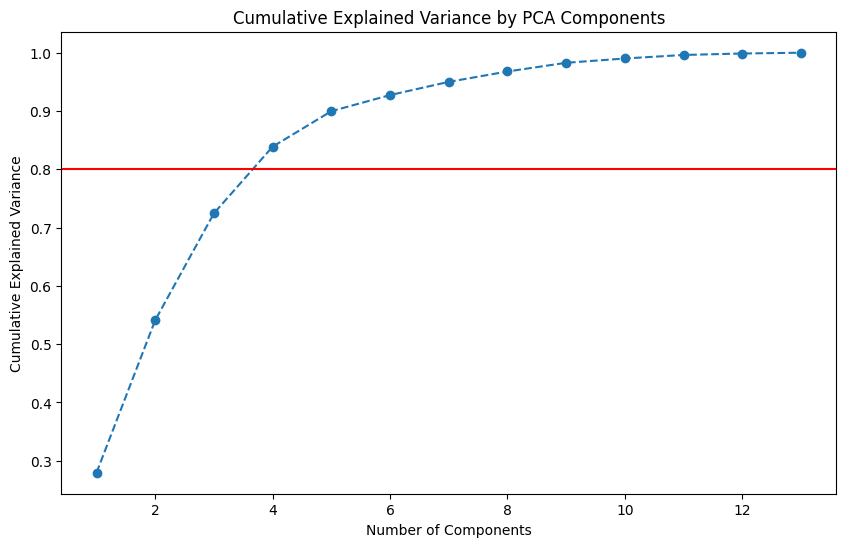

In [ ]:
# Initialise and Fit PCA
pca = PCA()
pca.fit(scaled_features_df)

# Create the Elbow Plot to see how many components to keep
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), np.cumsum(explained_variance), marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='-') # Aim for at least 80% variance
plt.show()

Finalizing the PCA Data

In [ ]:
# Create the PCA object with 4 components
pca_final = PCA(n_components=4)

# Fit and transform your scaled data
pca_4_df = pca_final.fit_transform(scaled_features_df)

# Look at your new simplified data
# You'll notice it only has 4 columns now: pca0, pca1, pca2, and pca3
pca_4_df.head()

,pca0,pca1,pca2,pca3
0,-0.094419,-0.757884,0.504083,0.438636
1,-0.017481,0.453019,0.384560,-0.225555
2,-0.126719,0.504107,0.471724,-0.230476
3,0.505367,0.184282,0.811681,-0.006984
4,0.542908,0.131782,0.744387,0.172948


Finding the Playlists (K-Means)

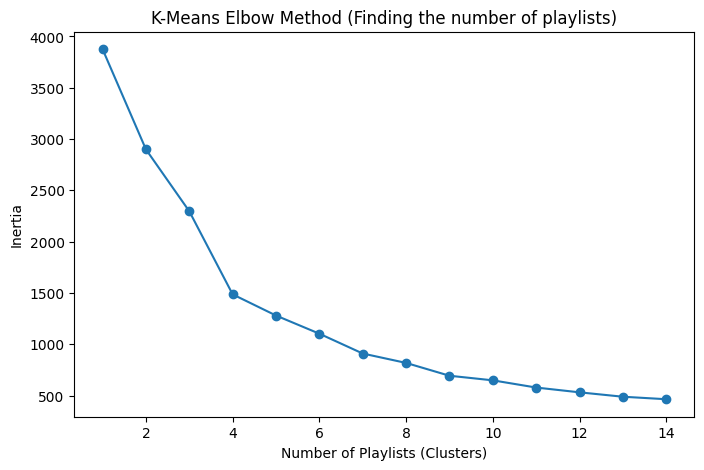

In [ ]:
inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_4_df)
    inertia.append(kmeans.inertia_)

# Plot the K-Means Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('K-Means Elbow Method (Finding the number of playlists)')
plt.xlabel('Number of Playlists (Clusters)')
plt.ylabel('Inertia')
plt.show()

Create the Playlists (K-Means): We will now train the model with $k=9$ and attach the results to your original list of songs.

In [ ]:
# Initialize K-Means with your chosen number of 9 clusters
kmeans_final = KMeans(n_clusters=9, random_state=42)

# Fit the model to your 3-component PCA data
clusters = kmeans_final.fit_predict(pca_4_df)

# Add the cluster assignments back to your original dataframe
# We use the original spotify_df so we can see the song names and artists
spotify_df['playlist_id'] = clusters

# Let's see the first few songs and their assigned playlist
spotify_df[['playlist_id']].head(10)

,playlist_id
0,3
1,7
2,7
3,2
4,2
5,2
6,4
7,2
8,8
9,7


Evaluate the Prototype (Showcasing Playlists)

In [ ]:
# Look at Playlist 0
print("--- MOOSIC PLAYLIST 0 ---")
display(spotify_df[spotify_df['playlist_id'] == 0].head(3))



--- MOOSIC PLAYLIST 0 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id
19,19,Brigas Nunca Mais ...,Brazilian Jazz,0.529,0.276,0,-14.859,1,0.0457,0.972,0.885,0.1330,0.280,96.134,,146800,4,5gvBgfXusUpxjOWHyYJXVg,https://open.spotify.com/track/5gvBgfXusUpxjOW...,0
21,21,Aquarela Do Brasil ...,Voyager,0.449,0.145,9,-19.732,1,0.0484,0.937,0.919,0.0769,0.304,91.330,,227400,3,3pjbCjL1IlqOfuQ8YOkX6o,https://open.spotify.com/track/3pjbCjL1IlqOfuQ...,0
47,47,Triste ...,Brazilian Jazz,0.610,0.340,2,-11.653,1,0.0340,0.906,0.859,0.0975,0.459,103.825,,131400,4,5v8WqKhW9CBk2WF9PAcSIw,https://open.spotify.com/track/5v8WqKhW9CBk2WF...,0


In [ ]:
# Look at Playlist 1
print("\n--- MOOSIC PLAYLIST 1 ---")
display(spotify_df[spotify_df['playlist_id'] == 1].head(3))


--- MOOSIC PLAYLIST 1 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id
202,202,Under Your Spell ...,Desire,0.572,0.599,8,-10.190,1,0.0334,0.027700,0.649,0.0938,0.474,105.555,,296400,4,38vNwoJygRx1u77aJOV8Zb,https://open.spotify.com/track/38vNwoJygRx1u77...,1
209,209,La Nueva Reconquista de Graná ...,Grupo De Expertos Solynieve,0.229,0.640,9,-7.361,1,0.0469,0.413000,0.755,0.0927,0.546,166.732,,238186,3,6Oj0gEBy4t8cYNX43u6cXd,https://open.spotify.com/track/6Oj0gEBy4t8cYNX...,1
224,224,"Que No Sea Kang, Por Favor ...",Los Planetas,0.435,0.494,2,-9.032,1,0.0279,0.000228,0.854,0.1600,0.228,93.997,,283587,4,41OGvdfzThkNxQVUkkWgq9,https://open.spotify.com/track/41OGvdfzThkNxQV...,1


In [ ]:
# Look at Playlist 2
print("\n--- MOOSIC PLAYLIST 2 ---")
display(spotify_df[spotify_df['playlist_id'] == 2].head(3))


--- MOOSIC PLAYLIST 2 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id
3,3,Mulher Eu Sei ...,Chico César,0.705,0.0502,4,-18.115,1,0.0471,0.879,0.000041,0.386,0.524,106.802,,186227,4,3mXqOdlLE1k67WsAxryPFs,https://open.spotify.com/track/3mXqOdlLE1k67Ws...,2
4,4,Rosa Morena ...,Kurt Elling,0.651,0.1190,6,-19.807,1,0.0380,0.916,0.000343,0.104,0.402,120.941,,273680,4,7bSzjzjTkWT2CkIPPdp0eA,https://open.spotify.com/track/7bSzjzjTkWT2CkI...,2
5,5,Desafinado ...,Stan Getz,0.466,0.1460,3,-17.500,1,0.0649,0.931,0.154000,0.107,0.423,142.885,,249387,4,5pstSsK0G4q86gdyy1Spqh,https://open.spotify.com/track/5pstSsK0G4q86gd...,2


In [ ]:
# Look at Playlist 3
print("\n--- MOOSIC PLAYLIST 3 ---")
display(spotify_df[spotify_df['playlist_id'] == 3].head(3))


--- MOOSIC PLAYLIST 3 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id
0,0,Se Eu Quiser Falar Com Deus ...,Gilberto Gil,0.658,0.259,11,-13.141,0,0.0705,0.694,0.000059,0.9750,0.306,110.376,,256213,4,1n7JnwviZ7zf0LR1tcGFq7,https://open.spotify.com/track/1n7JnwviZ7zf0LR...,3
12,12,Aqua De Coco ...,Marcos Valle,0.755,0.732,10,-9.600,0,0.0658,0.487,0.000910,0.4540,0.816,88.028,,287560,4,1OzHkIzGMj4S3rWwF8TBjc,https://open.spotify.com/track/1OzHkIzGMj4S3rW...,3
26,26,Karoliina Kaunis ...,Maria Gasolina,0.753,0.215,11,-15.671,0,0.2930,0.618,0.004640,0.0912,0.382,130.338,,251427,4,7BlLxHwobm2gHjXev9dNVe,https://open.spotify.com/track/7BlLxHwobm2gHjX...,3


In [ ]:
# Check the size of each playlist
playlist_counts = spotify_df['playlist_id'].value_counts().sort_index()
print("Number of songs per playlist:")
print(playlist_counts)

# Calculate the average
print(f"\nAverage songs per playlist: {len(spotify_df)/9:.0f}")

Number of songs per playlist:
playlist_id
0    378
1    650
2    536
3    603
4    304
5    349
6    596
7    901
8    918
Name: count, dtype: int64

Average songs per playlist: 582


In [ ]:
# Create 50 more specific playlists
kmeans_50 = KMeans(n_clusters=50, random_state=42)
spotify_df['playlist_id_refined'] = kmeans_50.fit_predict(pca_4_df)

# Check the new distribution
refined_counts = spotify_df['playlist_id_refined'].value_counts().sort_index()
print(f"New average songs per playlist: {len(spotify_df)/50:.0f}")
print(refined_counts.head(10)) # Look at the first 10

New average songs per playlist: 105
playlist_id_refined
0     93
1     89
2    159
3     98
4    124
5    116
6    114
7     82
8    121
9     43
Name: count, dtype: int64


In [ ]:
# Sample from 5 random refined playlists to see the difference
import random
sample_ids = random.sample(range(50), 5)

for i in sample_ids:
    print(f"--- REFINED PLAYLIST {i} ---")
    subset = spotify_df[spotify_df['playlist_id_refined'] == i]

    # Show the song titles (index) and artists
    if 'track_artist' in spotify_df.columns:
        print(subset[['track_artist']].sample(n=min(3, len(subset))))
    else:
        print(subset.index[:3].tolist())
    print("-" * 30)

--- REFINED PLAYLIST 48 ---
[22, 24, 44]
------------------------------
--- REFINED PLAYLIST 11 ---
[259, 263, 268]
------------------------------
--- REFINED PLAYLIST 34 ---
[256, 342, 558]
------------------------------
--- REFINED PLAYLIST 7 ---
[18, 1042, 1831]
------------------------------
--- REFINED PLAYLIST 40 ---
[202, 209, 290]
------------------------------


In [ ]:
# Loop through the first 5 playlists
# You can change 'range(5)' to 'range(50)' if you want to see all of them!
for i in range(5):
    print(f"--- MOOSIC PLAYLIST {i} ---")

    # Filter for the current playlist and show the top 3 rows
    # We use 'playlist_id_refined' (or whatever you named your new column)
    display(spotify_df[spotify_df['playlist_id_refined'] == i].head(3))
    print("\n" + "="*50 + "\n") # Adds a separator line between playlists

--- MOOSIC PLAYLIST 0 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id,playlist_id_refined
114,114,Violão Vadio ...,Raphael Rabello,0.364,0.0884,5,-21.309,1,0.0410,0.927,...,0.1270,0.152,89.235,,335993,4,5zE2UL4L0EAOl0do6kD3Hp,https://open.spotify.com/track/5zE2UL4L0EAOl0d...,0,0
239,239,Zamba del Carnaval ...,Hernán Ríos,0.520,0.1400,3,-19.627,1,0.0554,0.825,...,0.0766,0.150,91.277,,299453,3,6CjZXjIVOFAWrftsbQwu4m,https://open.spotify.com/track/6CjZXjIVOFAWrft...,0,0
1836,1836,Wishing ...,Alexis Ffrench,0.494,0.1230,3,-22.797,1,0.0347,0.995,...,0.1180,0.326,145.519,,128907,3,6yso76bQYrTpad7KvMjQ3S,https://open.spotify.com/track/6yso76bQYrTpad7...,0,0




--- MOOSIC PLAYLIST 1 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id,playlist_id_refined
271,271,Let’s Explode ...,Clem Snide,0.379,0.492,0,-7.451,1,0.0265,0.07310,...,0.346,0.222,104.520,,250200,4,3bdi228j2POsaAx8YMfi3Y,https://open.spotify.com/track/3bdi228j2POsaAx...,1,1
299,299,Someone for You ...,Warm Soda,0.227,0.995,0,-5.046,1,0.2160,0.00243,...,0.252,0.210,169.548,,138338,4,1jalG6lS08Gu8q16MgDbrC,https://open.spotify.com/track/1jalG6lS08Gu8q1...,1,1
316,316,Mirall ...,Les Sueques,0.485,0.527,2,-8.806,1,0.0257,0.36700,...,0.149,0.364,96.527,,268003,4,5mxzLPrYmE7IdyEQAqZNLF,https://open.spotify.com/track/5mxzLPrYmE7IdyE...,1,1




--- MOOSIC PLAYLIST 2 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id,playlist_id_refined
14,14,Mas Que Nada ...,Rio Combo,0.618,0.539,5,-12.689,0,0.0312,0.1560,...,0.187,0.916,88.646,,178880,4,51P5Djwsur61UY4oitktOQ,https://open.spotify.com/track/51P5Djwsur61UY4...,6,2
318,318,The Bags ...,Me and the Bees,0.488,0.897,7,-5.516,0,0.0461,0.1600,...,0.154,0.918,136.677,,90427,4,7LS7JG0SkumpwyTUXAo3Co,https://open.spotify.com/track/7LS7JG0SkumpwyT...,3,2
354,354,My Number ...,Foals,0.639,0.744,6,-8.377,0,0.0368,0.0319,...,0.466,0.825,128.047,,240533,4,4c9WmjVlQMr0s1IjbYO52Z,https://open.spotify.com/track/4c9WmjVlQMr0s1I...,3,2




--- MOOSIC PLAYLIST 3 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id,playlist_id_refined
10,10,The Girl From Ipanema ...,Stan Getz,0.641,0.140,8,-16.790,1,0.0390,0.867,...,0.1050,0.388,129.318,,317987,4,4xGFcQEIjtmbPD6Jsxq14M,https://open.spotify.com/track/4xGFcQEIjtmbPD6...,2,3
31,31,Team Zissou ...,Seu Jorge,0.619,0.402,7,-11.559,1,0.0354,0.870,...,0.0974,0.792,93.237,,152200,4,7bM4h5zu7FkChGbSeozZVN,https://open.spotify.com/track/7bM4h5zu7FkChGb...,2,3
34,34,Once Again ...,Stan Getz,0.623,0.331,8,-14.346,1,0.0372,0.846,...,0.0780,0.583,90.439,,402507,4,22QBm5IGpx49Ggg7b0DMhL,https://open.spotify.com/track/22QBm5IGpx49Ggg...,2,3




--- MOOSIC PLAYLIST 4 ---


,Unnamed: 0,name,artist,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,type,duration_ms,time_signature,id,html,playlist_id,playlist_id_refined
32,32,Parabens ...,Marcos Valle,0.737,0.802,7,-8.069,1,0.0424,0.01460,...,0.0897,0.476,109.821,,515787,4,596scNUBRpj2AygfaBVyTj,https://open.spotify.com/track/596scNUBRpj2Ayg...,8,4
166,166,Alegria ...,Batida,0.715,0.691,7,-8.953,1,0.0869,0.00331,...,0.1320,0.747,136.015,,215480,4,1K3JwmUeXS2g8OpRhtxtDO,https://open.spotify.com/track/1K3JwmUeXS2g8Op...,8,4
244,244,Dualize ...,L.A.,0.520,0.843,6,-4.157,1,0.0352,0.07840,...,0.1740,0.630,133.016,,159932,4,2PIC7KxAgHGYCGuGqcorw7,https://open.spotify.com/track/2PIC7KxAgHGYCGu...,8,4
